## EDA for House Price Prediction
### In this part of the project we will analyze the housing price 

### 1. Import Libraries and Load Data
We import pandas for data handling and load the cleaned dataset produced by the scraping and cleaning pipeline (`test_scrape.py` and `clean_data.py`).

In [2]:
import pandas as pd
df = pd.read_csv("clean_listings.csv")
df.head()

,url,price_etb,bedrooms,property_type,size_m2,sub_city,furnished
0,https://jiji.com.et/bole/houses-apartments-for...,100000,3,Villa,NaN,Bole,True
1,https://jiji.com.et/bole/houses-apartments-for...,200000,3,Apartment,NaN,Bole,True
2,https://jiji.com.et/bole/houses-apartments-for...,250000,5,Villa,NaN,Bole,True
3,https://jiji.com.et/bole/houses-apartments-for...,250000,3,Villa,NaN,Bole,False
4,https://jiji.com.et/bole/houses-apartments-for...,80000,2,Apartment,NaN,Bole,True


### 2. Data Understanding
We inspect the structure, types, and summary statistics of the dataset before any cleaning.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   url            798 non-null    str    
 1   price_etb      798 non-null    int64  
 2   bedrooms       798 non-null    int64  
 3   property_type  795 non-null    str    
 4   size_m2        44 non-null     float64
 5   sub_city       798 non-null    str    
 6   furnished      798 non-null    bool   
dtypes: bool(1), float64(1), int64(2), str(3)
memory usage: 38.3 KB


In [4]:
df.describe()

,price_etb,bedrooms,size_m2
count,798.000000,798.000000,44.000000
mean,158077.317043,2.942356,213.250000
std,132525.062404,1.702220,138.780088
min,20000.000000,0.000000,1.000000
25%,75000.000000,2.000000,143.750000
50%,120000.000000,3.000000,185.000000
75%,192400.000000,3.000000,250.000000
max,940000.000000,20.000000,800.000000


The dataset contains 798 rows and 7 columns. `price_etb` and `bedrooms` are numeric, `furnished` is boolean, and the remaining columns are text. `size_m2` and `property_type` show missing values, which we address in the next section.

### 3. Data Cleaning
Before analysis, we check for duplicate rows, missing values, and invalid entries, and engineer one new feature (`location_group`) to support later analysis.

#### 3.1. Handling Duplicate Rows

In [5]:
df.duplicated().sum()

np.int64(0)

Since we cleaned and removed the duplicates during data scraping and extraction , we don't have duplicates.

#### 3.2 Handling Missing Values


In [6]:
df.isnull().sum()

url                0
price_etb          0
bedrooms           0
property_type      3
size_m2          754
sub_city           0
furnished          0
dtype: int64

Since size_m2 column has missing in over 90% of rows everywhere, no subcity pattern to exploit, the only reasonable fix is to drop the column entirely.
But property_type has only 3 missing rows out of 798 small enough to just drop those specific rows rather than impute or guess. 
While the rest columns have technically zero missing values we keep them.


In [7]:
df=df.drop(columns=["size_m2"])
df=df.dropna(subset=["property_type"])
df.isnull().sum()


url              0
price_etb        0
bedrooms         0
property_type    0
sub_city         0
furnished        0
dtype: int64

#### 3.3 Removing Invalid Values
 A valid rental must have a positive price and non-negative bedroom count

In [8]:
### Check for non-positive bedrooms
df[df["bedrooms"]<0]

,url,price_etb,bedrooms,property_type,sub_city,furnished


In [9]:
# Check for non-positive prices
df[df["price_etb"]<=0]

,url,price_etb,bedrooms,property_type,sub_city,furnished


From the above results we see that there is no invalid values in our data set.

In [10]:
# Look at the current price range
df["price_etb"].describe()

count       795.000000
mean     157670.061635
std      131078.577789
min       20000.000000
25%       75000.000000
50%      120000.000000
75%      191600.000000
max      940000.000000
Name: price_etb, dtype: float64

In [11]:
df["price_etb"].sort_values(ascending=False).head(10)

173    940000
53     930000
369    900000
215    800000
727    800000
36     800000
362    800000
383    790000
785    700000
356    700000
Name: price_etb, dtype: int64

In [12]:
df["price_etb"].sort_values().head(10)

781    20000
525    25000
725    25000
724    29999
368    30000
361    30000
652    30000
672    30000
407    32000
532    35000
Name: price_etb, dtype: int64

The lowest prices (ETB 20,000–35,000) correspond to small unfurnished apartments, while the highest (ETB 700,000–940,000) correspond to furnished villas and penthouses — both consistent with real listings seen in the raw data. No invalid values remain after outlier filtering during the data cleaning stage.

### 3.4 Creating Location Group Feature

Sub-cities with substantial representation (160+ listings) get their own category.
Sparse sub-cities (under 60 listings) are grouped into "Other" to avoid the model
overfitting on categories with too few examples.

In [14]:
common_subcities = ["Bole", "Kirkos", "Yeka", "Nifas Silk-Lafto"]
def group_location(city):
    if city in common_subcities:
        return city
    else :
     return "Other"
df["location_group"]=df["sub_city"].apply(group_location)
# Verify the new grouping
df["location_group"].value_counts()

location_group
Yeka                179
Kirkos              177
Bole                176
Nifas Silk-Lafto    161
Other               102
Name: count, dtype: int64

This results in five location categories: Yeka (179), Kirkos (177), Bole (176), Nifas Silk-Lafto (161), and Other (102) — each with enough representation to support reliable analysis.

### 4. Data Analysis

#### 4.1 Price by Location Group

In [15]:
location_stats = df.groupby("location_group")["price_etb"].agg(["count","mean","median"])
location_stats = location_stats.sort_values("median",ascending=False)
location_stats


,count,mean,median
location_group,,,
Bole,176,214920.454545,172500.0
Kirkos,177,162906.779661,150000.0
Other,102,166041.166667,130000.0
Nifas Silk-Lafto,161,160186.335404,90000.0
Yeka,179,89167.597765,70000.0


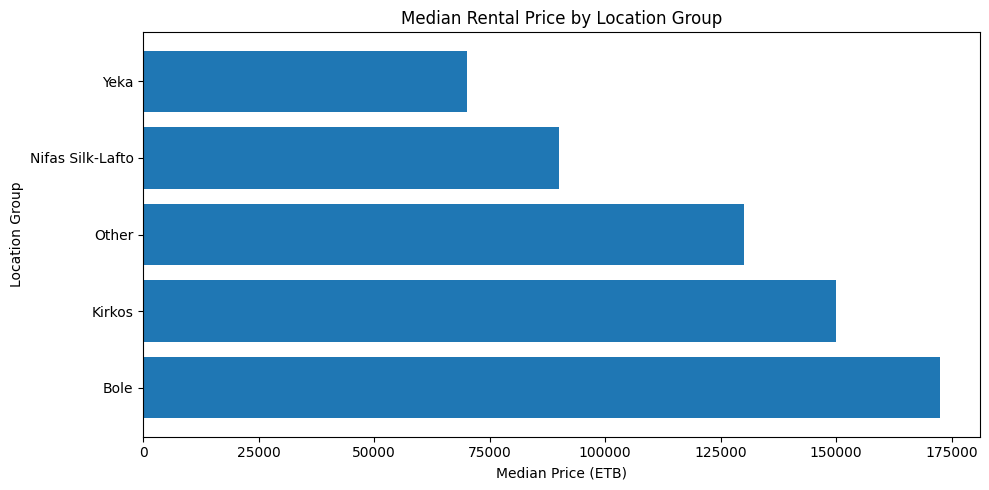

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(location_stats.index,location_stats["median"])
plt.xlabel("Median Price (ETB)")
plt.ylabel("Location Group")
plt.title("Median Rental Price by Location Group")
plt.tight_layout()
plt.show()


##### Key Insights

1. **Bole** is the most expensive sub-city with a median rent of ETB 172,500 — more than double Yeka's 70,000.
2. **Kirkos** ranks second at ETB 150,000, reflecting its status as a premium commercial and residential area.
3. The **"Other" group** sits at ETB 130,000, surprisingly higher than both Nifas Silk-Lafto and Yeka. This is likely because sparse sub-cities tend to have fewer but more upscale listings, skewing their median upward — a known limitation of this dataset.
4. **Yeka** is the most affordable named sub-city at ETB 70,000, nearly 2.5x cheaper than Bole despite being within the same city.
5. The wide price gap across sub-cities confirms that **location is a strong driver of rental price** in Addis Ababa.

##### Conclusion

Location group reveals a clear and meaningful price hierarchy across Addis Ababa. Bole commands the highest typical rent while Yeka sits at the lower end among well-represented sub-cities. Given this strong variation, `location_group` is expected to be one of the most significant predictors in the model.

#### 4.2 Price by Property Type  

In [17]:
property_stats= df.groupby("property_type")["price_etb"].agg(["count","mean","median"])
property_stats=property_stats.sort_values("median", ascending=False)
property_stats

,count,mean,median
property_type,,,
Penthouse,18,307500.000000,275000.0
House,108,253796.287037,180000.0
Duplex,5,298000.000000,175000.0
Villa,56,221035.714286,165000.0
Apartment,608,129168.914474,100000.0


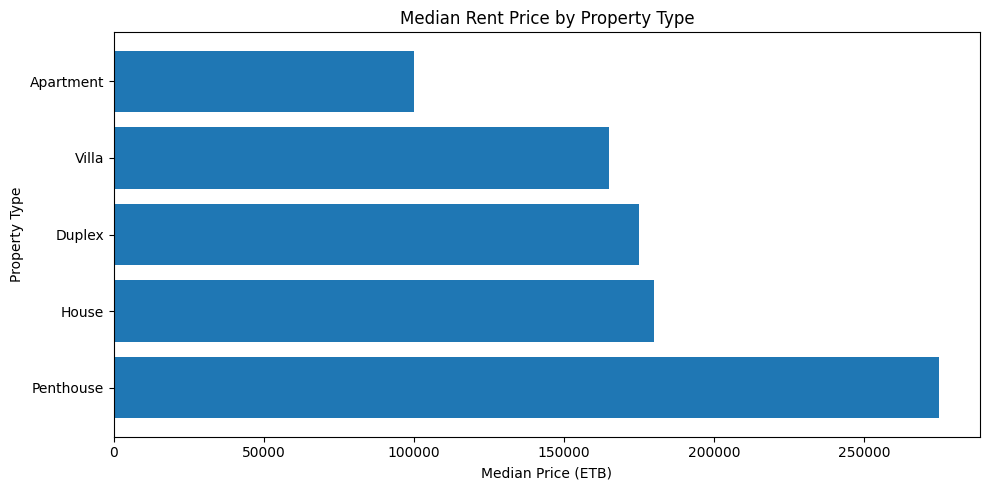

In [18]:
plt.figure(figsize=(10,5))
plt.barh(property_stats.index,property_stats["median"])
plt.xlabel("Median Price (ETB)")
plt.ylabel("Property Type")
plt.title("Median Rent Price by Property Type")
plt.tight_layout()
plt.show()

##### Key Insights

1. **Penthouse** commands the highest median rent at ETB 275,000, reflecting its premium 
status as a luxury property type in Addis Ababa.
2. **Villa** (ETB 165,000) is surprisingly cheaper than **House** (ETB 180,000) — this may 
reflect that many villas in the dataset are located in more affordable sub-cities like Yeka 
or Nifas Silk-Lafto, while houses tend to cluster in premium areas like Bole.
3. **Duplex** has only 5 listings, making its median of ETB 175,000 statistically unreliable 
— this category should be interpreted with caution.
4. **Apartment** dominates the dataset with 608 out of 795 listings (76%), reflecting the 
reality of Addis Ababa's rental market where apartments are by far the most common 
listing type on Jiji.
5. The price gap between the most expensive type (Penthouse, ETB 275,000) and the most 
common type (Apartment, ETB 100,000) is 2.75x, confirming that property type is a 
meaningful price differentiator.

##### Conclusion

Property type shows a clear price hierarchy with Penthouse at the top and Apartment at 
the bottom. However, the dataset is heavily skewed toward Apartments (76%), which may 
limit the model's ability to learn strong signals for rarer property types like Duplex and 
Penthouse. Despite this, `property_type` remains a useful predictor alongside 
`location_group`.

#### 4.3 Price by Bedrooms

In [19]:
bedroom_stats=df.groupby("bedrooms")["price_etb"].agg(["count","mean","median"])
bedroom_stats=bedroom_stats.sort_values("bedrooms",ascending=True)
bedroom_stats = bedroom_stats[bedroom_stats.index <= 8]
bedroom_stats

,count,mean,median
bedrooms,,,
0,7,75714.285714,80000.0
1,85,76958.811765,65000.0
2,221,107148.868778,90000.0
3,332,163724.397590,142500.0
4,58,251565.517241,177500.0
5,45,280533.333333,180000.0
6,22,267045.454545,215000.0
7,8,260000.000000,215000.0
8,9,272222.222222,200000.0


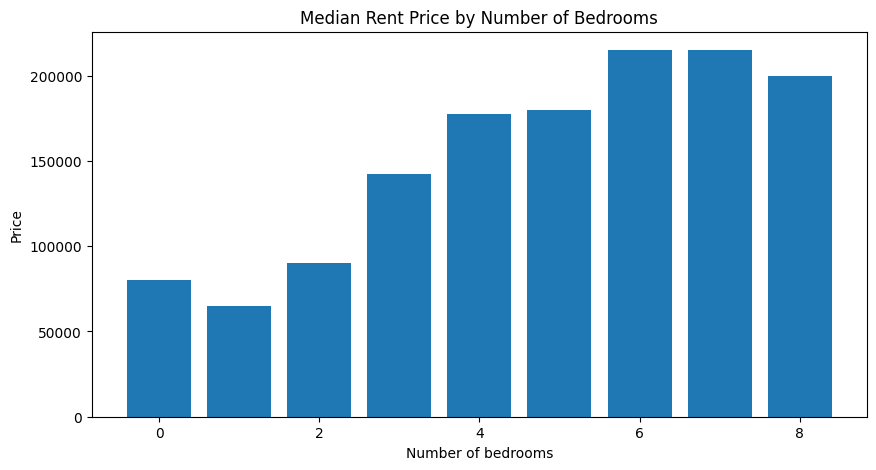

In [20]:
plt.figure(figsize=(10,5))
plt.bar(bedroom_stats.index,bedroom_stats["median"])
plt.xlabel("Number of bedrooms")
plt.ylabel("Price")
plt.title("Median Rent Price by Number of Bedrooms")
plt.tight_layout
plt.show()

##### Key Insights

1. **Price generally rises with bedroom count**, confirming that the number of bedrooms 
is a meaningful predictor of rental price in Addis Ababa.

2. **Studios (0 bedrooms) have a higher median price (ETB 80,000) than 1-bedroom units 
(ETB 65,000).** This is likely because studios in Addis Ababa tend to be modern, 
fully-furnished units targeting expats or professionals, commanding a premium despite 
their smaller size.

3. **The sharpest price jump occurs between 2 and 3 bedrooms** — from ETB 90,000 to 
ETB 142,500 (a 58% increase). This suggests that 3-bedroom units represent a 
significant market tier shift, likely from individual renters to families or 
shared professional housing.

4. **Listings with 7 or 8 bedrooms have very few entries (8 and 9 respectively),** 
making their medians statistically unreliable. Large-bedroom properties are rare 
on Jiji, and their pricing patterns should be interpreted with caution.

5. **Price growth plateaus between 6 and 8 bedrooms**, all clustering around ETB 
200,000–215,000. This suggests diminishing returns at the high end — the market 
for very large rentals is thin and pricing becomes inconsistent.

##### Conclusion

Bedroom count shows a clear positive relationship with rental price, with the most 
significant jump occurring between 2 and 3 bedrooms. However, the relationship 
weakens at higher bedroom counts due to limited listings and market thinness. 
`bedrooms` is a useful predictor, particularly in the 1–6 bedroom range where 
data is most reliable.

#### 4.4 Overall Price Distribution

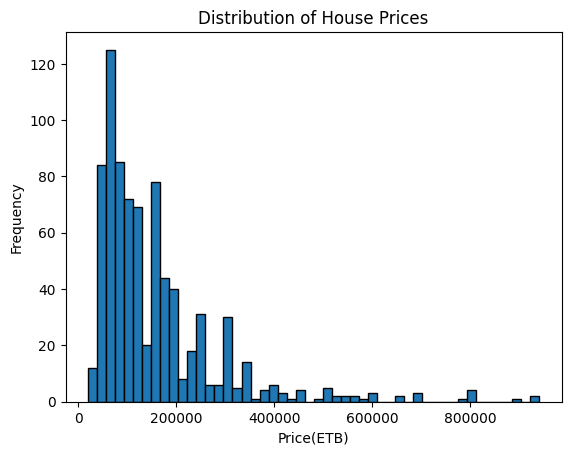

In [21]:
plt.hist(df["price_etb"],bins=50,edgecolor="black")
plt.xlabel("Price(ETB)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()


##### Key Insights

1. **The distribution is heavily right-skewed.** Most listings are concentrated 
in the lower price range, with a long tail of expensive properties stretching 
toward ETB 940,000. This confirms why the mean is higher than the median — 
a handful of luxury listings pull the average upward artificially.

2. **The bulk of listings cluster between ETB 50,000 and ETB 200,000**, with 
the peak frequency around ETB 75,000–100,000. This represents the typical 
Addis Ababa rental on Jiji, meaning most renters are paying well below the 
medians seen in premium sub-cities like Bole (ETB 172,500).

3. **The tail beyond ETB 400,000 is sparse and scattered**, with isolated 
listings extending to ETB 940,000. These extreme values can distort a 
regression model by forcing it to balance fitting the dense low-price 
cluster against a few outliers. This is a strong signal that log-transforming 
`price_etb` before modeling is worth testing.

##### Conclusion

The price distribution is heavily right-skewed, with most rentals priced 
under ETB 200,000 and a sparse luxury tail extending to nearly ETB 940,000. 
This has a direct modeling implication — a log transformation of `price_etb` 
should be considered before training, as skewed targets typically hurt the 
performance of linear models like Linear Regression.

#### 4.5 Furnished vs Unfurnished

In [23]:
furnished_stats=df.groupby("furnished")["price_etb"].agg(["count","mean","median"])
furnished_stats

,count,mean,median
furnished,,,
False,363,141448.482094,90000.0
True,432,171300.694444,150000.0


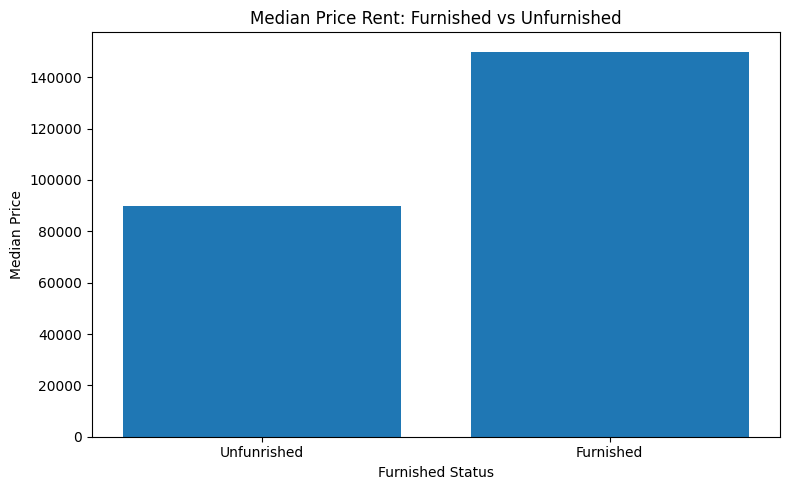

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(["Unfurnished","Furnished"],furnished_stats["median"])
plt.title("Median Price Rent: Furnished vs Unfurnished")
plt.xlabel("Furnished Status")
plt.ylabel("Median Price")
plt.tight_layout()
plt.show()

##### Key Insights

1. **In this dataset, furnished listings (432) slightly outnumber unfurnished 
ones (363).** This may reflect the portion of the Addis Ababa rental market 
captured on Jiji, which tends to attract landlords targeting expats, diplomats, 
and short-term professional tenants — though this ratio may not represent the 
broader market.

2. **Furnished properties command a significant 67% price premium** — a median of 
ETB 150,000 compared to ETB 90,000 for unfurnished units. This is one of the 
largest price differentials observed across all features analyzed so far.

3. **The premium is expected but worth quantifying.** Furnished properties include 
additional value (furniture, appliances, often utilities) that justifies higher 
rent. However, since the `furnished` flag was extracted from free text using 
keyword matching, there is a small risk of misclassification where listings 
mentioning "furnished" in passing were incorrectly labeled — a known limitation 
of text-based parsing.

##### Conclusion

The 67% price gap between furnished and unfurnished listings is substantial and 
consistent with market expectations. Despite the parsing limitation, `furnished` 
is a meaningful feature and should be included as a predictor in the model. 
Combined with `location_group`, `property_type`, and `bedrooms`, it forms part 
of a well-rounded feature set for rental price prediction.

## 5. Final Insights & Recommendations

### 🔍 Key Findings

From the analysis of 795 rental listings scraped from Jiji.com.et, 
several important patterns emerge:

#### 1. Location is the Strongest Price Driver
Bole commands the highest median rent at ETB 172,500 — more than double 
Yeka's ETB 70,000, the most affordable named sub-city. Location group 
alone creates a 2.5x price gap across the city, making it the single 
most influential feature in this dataset.

#### 2. Property Type Creates a Clear Price Hierarchy
Penthouses (ETB 275,000) sit at the top while Apartments (ETB 100,000) 
are the most affordable — and by far the most common, representing 76% 
of all listings. This dominance of Apartments is a known characteristic 
of this dataset that may limit the model's ability to learn strong 
signals for rarer property types like Duplex and Penthouse.

#### 3. Bedroom Count Shows a Strong Positive Relationship with Price
Price generally rises with bedroom count, with the sharpest jump 
occurring between 2 bedrooms (ETB 90,000) and 3 bedrooms (ETB 142,500) 
— a 58% increase. Studios (0 bedrooms) are an exception, pricing higher 
than 1-bedroom units, likely due to their modern furnished nature 
targeting professionals and expats.

#### 4. Furnished Properties Command a Significant Premium
Furnished listings have a median price 67% higher than unfurnished ones 
(ETB 150,000 vs ETB 90,000), making furnished status one of the most 
impactful binary features in the dataset.

### 📈 Interpretation

All four features — `location_group`, `property_type`, `bedrooms`, and 
`furnished` — show meaningful relationships with rental price and are 
worth carrying forward into the modeling stage. The price distribution 
is heavily right-skewed, suggesting that a log transformation of 
`price_etb` should be tested before training linear models.

Known limitations of this dataset include the dominance of Apartment 
listings (76%), geographic concentration in Bole and Kirkos, sparse 
representation of some sub-cities grouped into "Other", and the 
text-based parsing of the `furnished` flag which carries a small risk 
of misclassification.

### 🧠 Conclusion

This EDA reveals that rental prices in Addis Ababa are primarily driven 
by location, property type, bedroom count, and furnished status — in 
that order of observed impact. These four features form the foundation 
of the predictive model to be built in the next stage. The dataset, 
while limited to Jiji listings and subject to the data quality 
constraints documented above, provides a solid and representative 
starting point for rental price prediction in Addis Ababa.